##### Import statements:

In [2]:
import os
import pathlib
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from matplotlib import colormaps
from analysis_metadata.analysis_metadata import Metadata, increment_dir_name, write_metadata

##### Define inputs, parameters:

In [48]:
# Input file:
input_path = os.path.join('/', 'mnt', 'smb', 'locker', 'issa-locker', 'users', 'Dan', 'code', 'ws', 'results', 'run845', 'tngl_pred.pickle')
input_dir = os.path.split(input_path)[0]

# Output parameters:
save_output = True
base_dir_name = 'ps_post_v_ps_pre'

##### Load previously-saved results:

In [49]:
tngl_evo_pred_results = pickle.load(open(input_path, 'rb'))
geo_df = tngl_evo_pred_results['geo_df'] 
loss_df = tngl_evo_pred_results['ae_df']

##### Select results for prediction model, hidden layer:

In [50]:
geo_df_pred = geo_df[geo_df.mdl_type=='prediction']
geo_df_pred_hidden = geo_df_pred[geo_df_pred.layer=='hidden']

##### For each model, find results for first and last epochs, merge:

In [51]:
# Get first epoch results:
geo_df_pred_hidden_e0 = geo_df_pred_hidden[geo_df_pred_hidden.epoch==0]
geo_df_pred_hidden_e0 = geo_df_pred_hidden_e0.rename(columns={'parallelism':'parallelism_e0'}) 

# Get final epoch results:
max_epoch_df = geo_df_pred_hidden[['pred_mdl_id', 'epoch']].groupby('pred_mdl_id').max().reset_index()
geo_df_pred_hidden_efinal = pd.merge(geo_df_pred_hidden, max_epoch_df, on=['pred_mdl_id', 'epoch'])
geo_df_pred_hidden_efinal = geo_df_pred_hidden_efinal.rename(columns={'parallelism':'parallelism_efinal'}) 

# Merge on model id:
ps_history_df = pd.merge(geo_df_pred_hidden_e0[['pred_mdl_id', 'dichotomy_idx', 'train_partition_inds', 'parallelism_e0']],\
      geo_df_pred_hidden_efinal[['pred_mdl_id', 'dichotomy_idx', 'train_partition_inds','parallelism_efinal']],\
      on=['pred_mdl_id', 'dichotomy_idx', 'train_partition_inds'])

##### Compute mean initial and final hidden-layer PS for each model:

In [52]:
scatter_df = ps_history_df.groupby(['pred_mdl_id', 'dichotomy_idx']).mean()\
    .groupby('pred_mdl_id').mean().reset_index()

##### Scatter prediction model hidden layer final epoch parallelism $\text{PS}(h^{\text{final}}_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i))$ vs prediction model hidden layer first epoch parallelism  $\text{PS}(h^{\text{random}}_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i))$: 

Text(0, 0.5, '$\\text{PS}\\left(h^{\\text{final}}_{\\text{prediction}_i} \\circ h_{\\text{entangler}}(\\mathbf{X}_i)\\right)$')

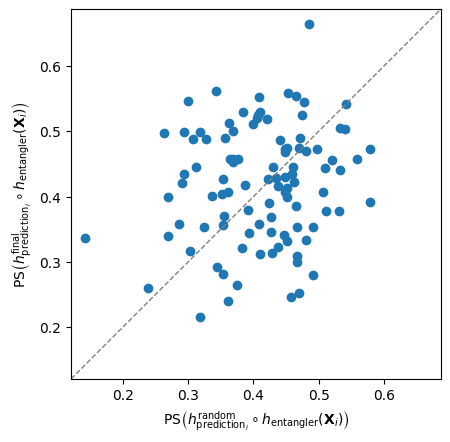

In [57]:
scatter_fig, scatter_ax = plt.subplots()
plt.scatter(scatter_df.parallelism_e0, scatter_df.parallelism_efinal)

# Set axes equal:
yl = plt.ylim()
xl = plt.xlim()
minmin = np.min([xl[0], yl[0]])
maxmax = np.max([xl[1], yl[1]])
plt.xlim([minmin, maxmax])
plt.ylim([minmin, maxmax])
scatter_ax.set_aspect('equal')

# Add unity line:
plt.axline([0,0], slope=1, color='gray', linewidth=1, linestyle='--')

# Add axis labels:
xlabel = r'$\text{PS}\left(h^{\text{random}}_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i)\right)$'
ylabel = r'$\text{PS}\left(h^{\text{final}}_{\text{prediction}_i} \circ h_{\text{entangler}}(\mathbf{X}_i)\right)$'
plt.xlabel(xlabel)
plt.ylabel(ylabel)